<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Ecommerece%20Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("umuttuygurr/e-commerce-fraud-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/e-commerce-fraud-detection-dataset


In [3]:
import os

print(os.listdir(path))

['transactions.csv']


In [4]:
import pandas as pd

file_path = path + "/transactions.csv"  # Corrected file path
df = pd.read_csv(file_path)

df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

# Data Preprocessing

In [7]:
df.isna().sum() / len(df)

,0
transaction_id,0.0
user_id,0.0
account_age_days,0.0
total_transactions_user,0.0
avg_amount_user,0.0
amount,0.0
country,0.0
bin_country,0.0
channel,0.0
merchant_category,0.0


In [8]:
df.duplicated().sum()

np.int64(0)

## Outlier Handling

In [9]:
df.drop(['transaction_id', 'user_id'], axis=1, inplace=True)

In [10]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

df['hour'] = df['transaction_time'].dt.hour
df['day'] = df['transaction_time'].dt.day
df['month'] = df['transaction_time'].dt.month
df['weekday'] = df['transaction_time'].dt.weekday

df.drop('transaction_time', axis=1, inplace=True)

The `feature_names` variable below, previously set incorrectly, will be updated to use `continuous_features` for the `get_knn` function and `MaxAbsScaler` to ensure it operates on the relevant numerical columns. This aligns with the outlier handling steps performed earlier.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00
shipping_distance_km,299695.0,357.049028,427.672074,0.00,136.60,273.02,409.18,3748.56
is_fraud,299695.0,0.022062,0.146887,0.00,0.00,0.00,0.00,1.00


In [12]:
continuous_features = [
    'account_age_days',
    'total_transactions_user',
    'avg_amount_user',
    'amount',
    'shipping_distance_km'
]

In [13]:
import pandas as pd

outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,avg_amount_user,46.19,173.45,-144.700,364.340,23890
1,amount,42.10,191.11,-181.415,414.625,26711
2,promo_used,0.00,0.00,0.000,0.000,46045
3,avs_match,1.00,1.00,1.000,1.000,48551
4,cvv_result,1.00,1.00,1.000,1.000,38328
5,three_ds_flag,1.00,1.00,1.000,1.000,64558
6,shipping_distance_km,136.60,409.18,-272.270,818.050,20312
7,is_fraud,0.00,0.00,0.000,0.000,6612


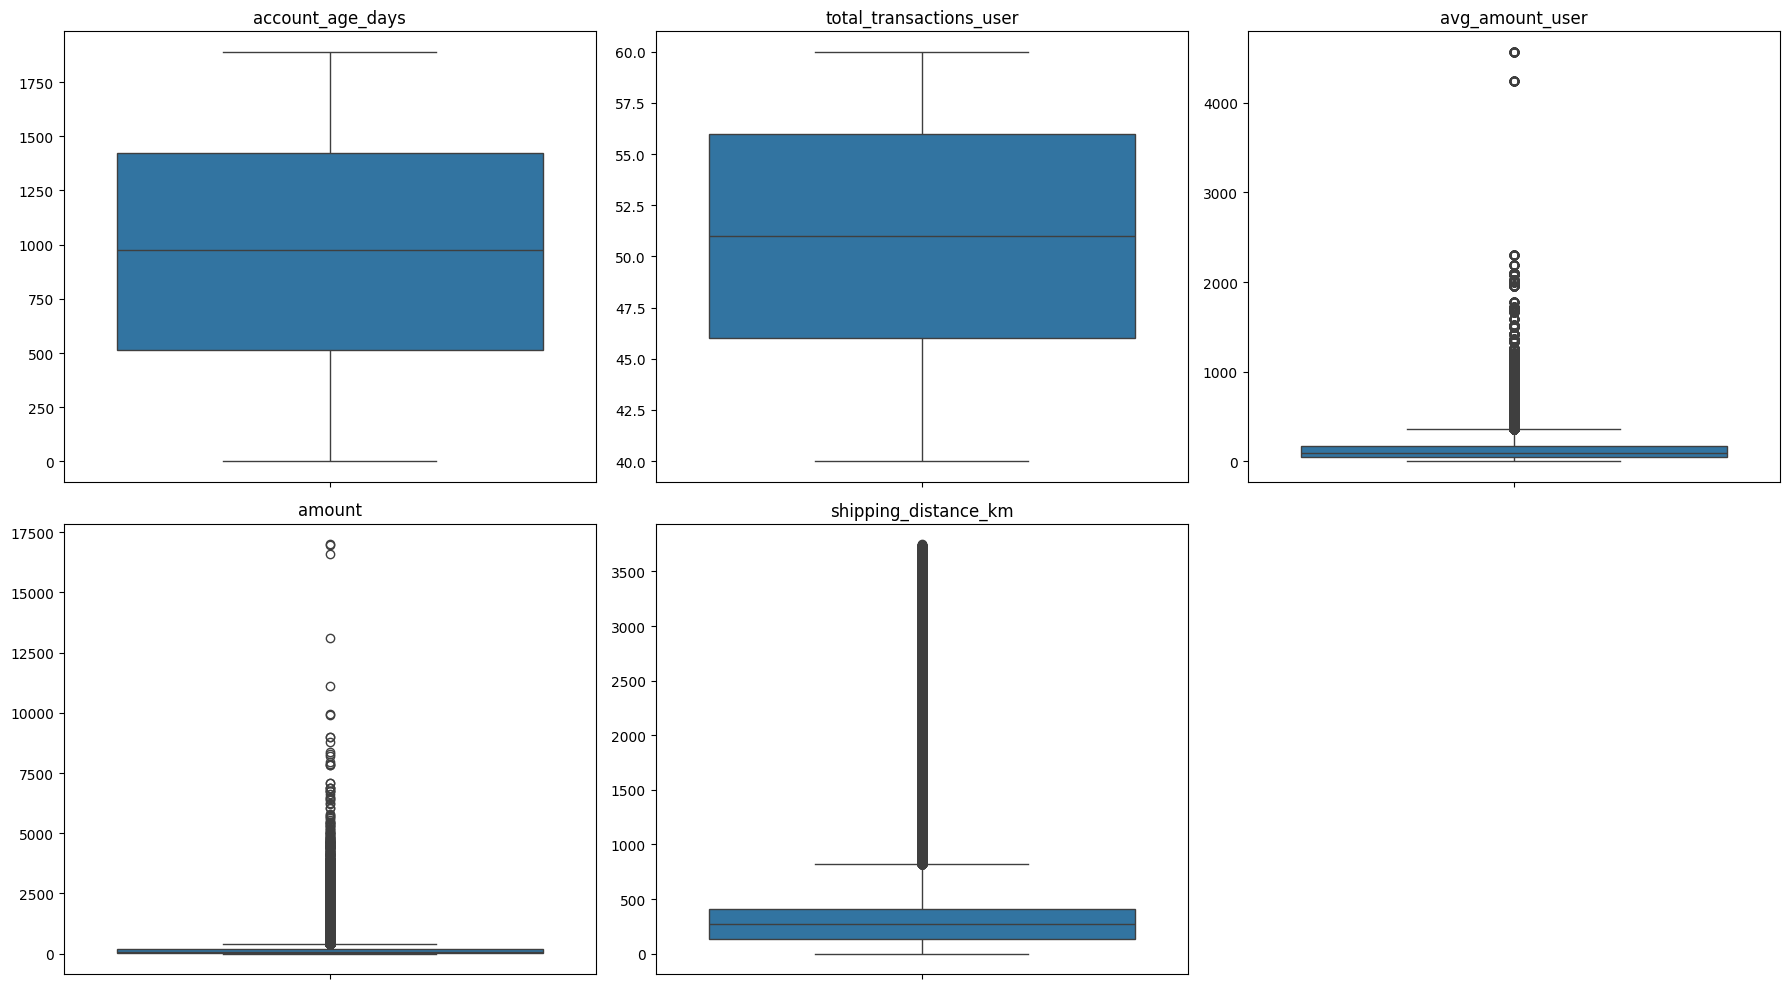

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features # Using the correct list of features

rows = 2 # 5 features, so 2 rows with 3 columns per row is sufficient (2*3=6)
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes): # Ensure we don't go out of bounds if there are more features than subplots
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)): # Remove unused subplots
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[feature] = df[feature].clip(lower, upper)

print("Outliers have been capped.")

Outliers have been capped.


In [16]:
capped_summary = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

capped_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,account_age_days,516.00,1425.00,-847.500,2788.500,0
1,total_transactions_user,46.00,56.00,31.000,71.000,0
2,avg_amount_user,46.19,173.45,-144.700,364.340,0
3,amount,42.10,191.11,-181.415,414.625,0
4,shipping_distance_km,136.60,409.18,-272.270,818.050,0


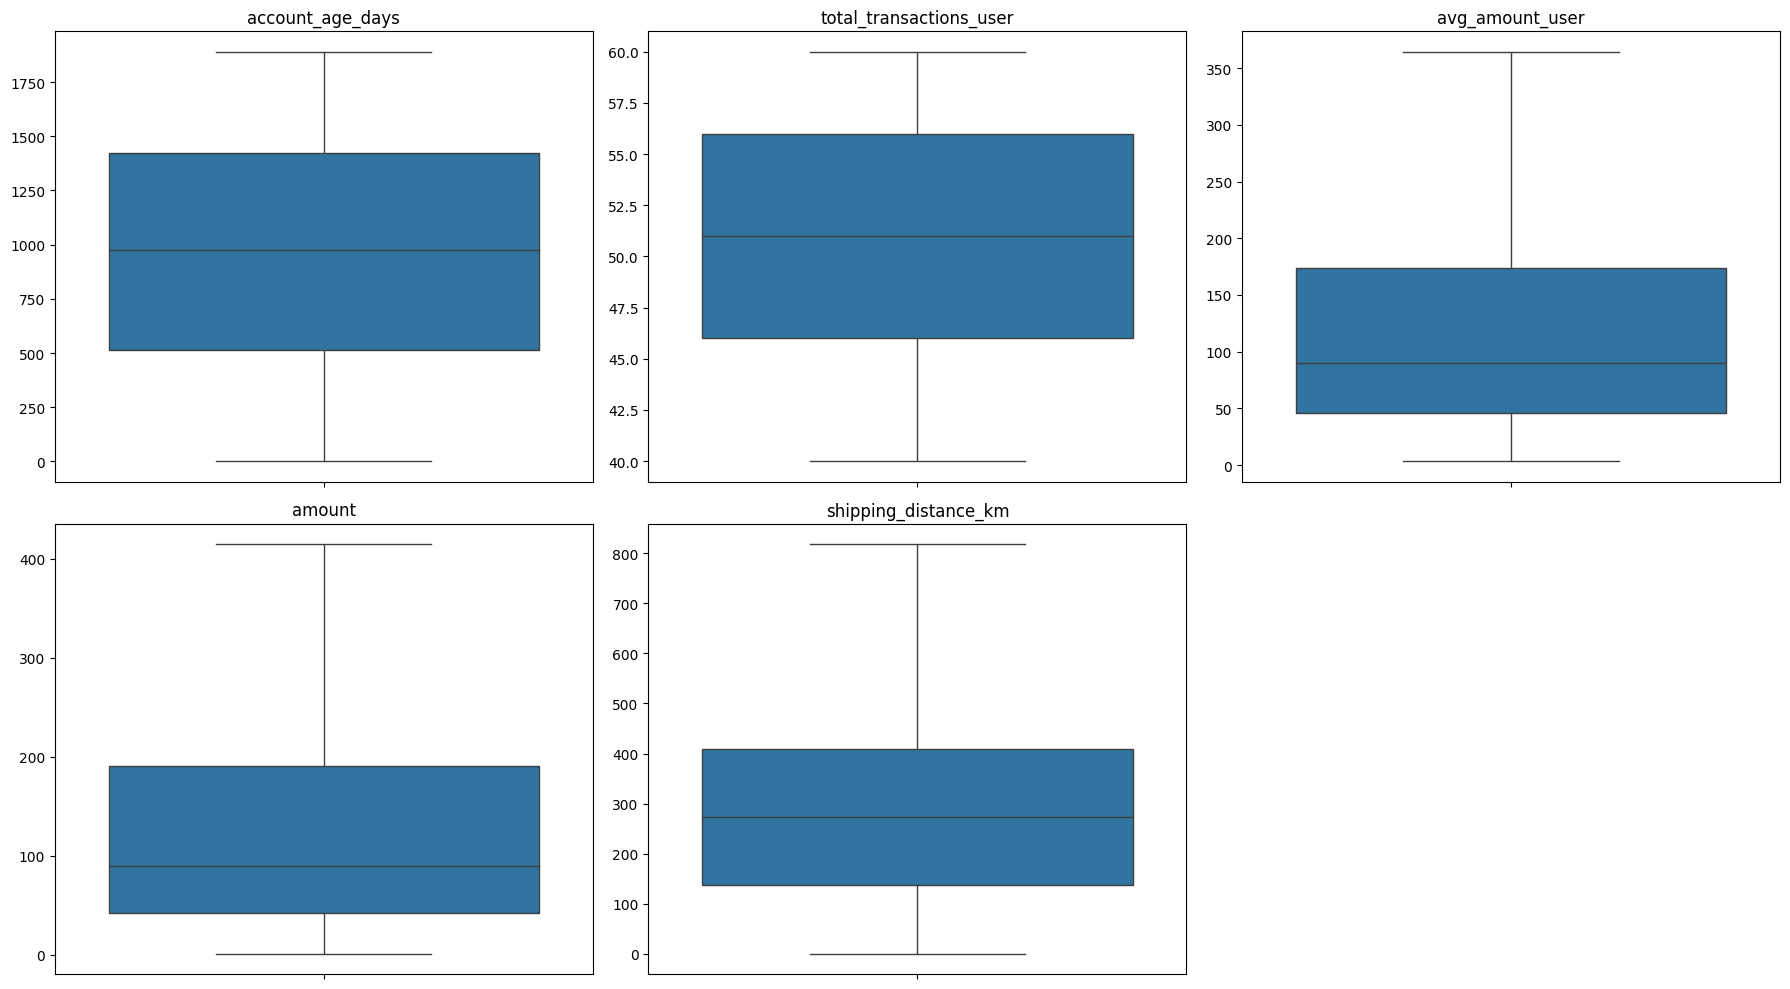

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = continuous_features # Using the correct list of features

rows = 2 # 5 features, so 2 rows with 3 columns per row is sufficient (2*3=6)
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes): # Ensure we don't go out of bounds if there are more features than subplots
        sns.boxplot(y=df[feature], ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_ylabel('')

for j in range(len(numeric_features), len(axes)): # Remove unused subplots
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data Aggregation

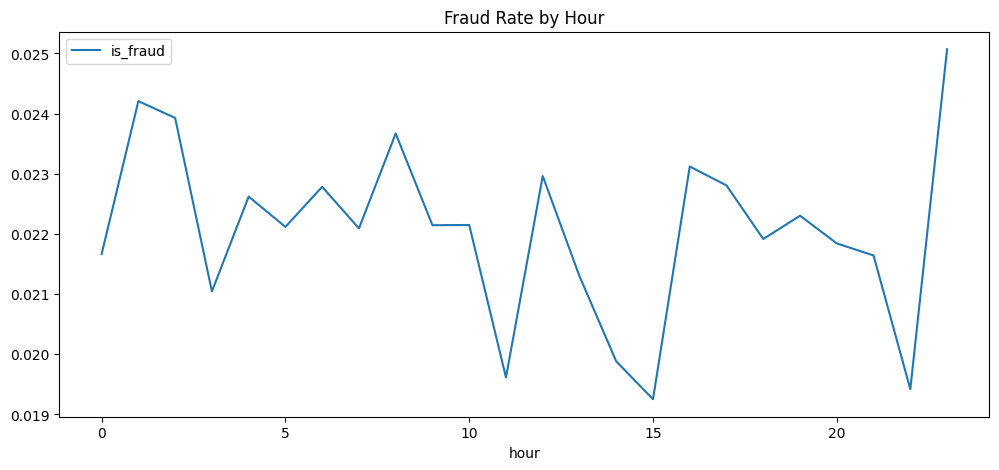

In [18]:
agg_hour = pd.pivot_table(
    data=df,
    index='hour',
    values='is_fraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))
sns.lineplot(data=agg_hour)
plt.title('Fraud Rate by Hour')
plt.show()

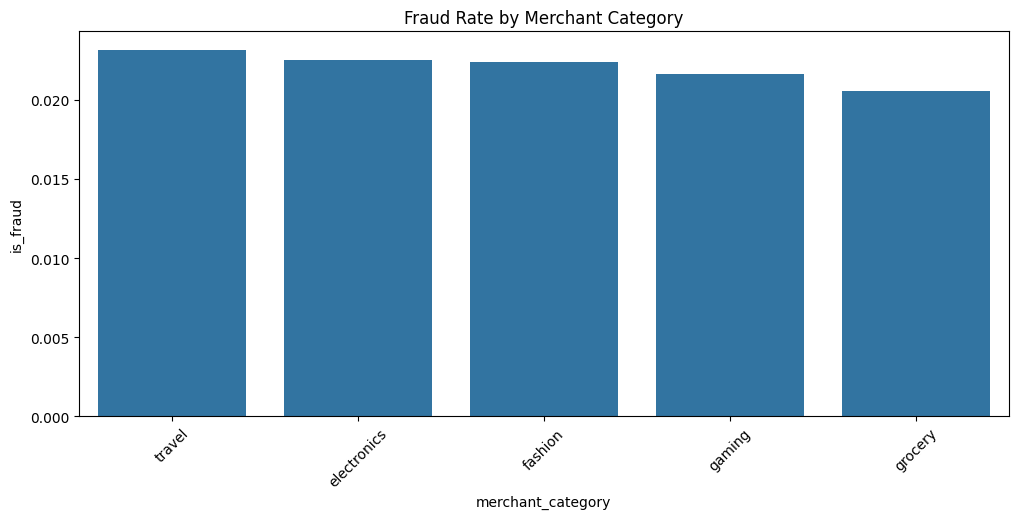

In [19]:
agg_merchant = pd.pivot_table(
    data=df,
    index='merchant_category',
    values='is_fraud',
    aggfunc='mean'
).sort_values(by='is_fraud', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=agg_merchant.index, y=agg_merchant['is_fraud'])
plt.xticks(rotation=45)
plt.title('Fraud Rate by Merchant Category')
plt.show()

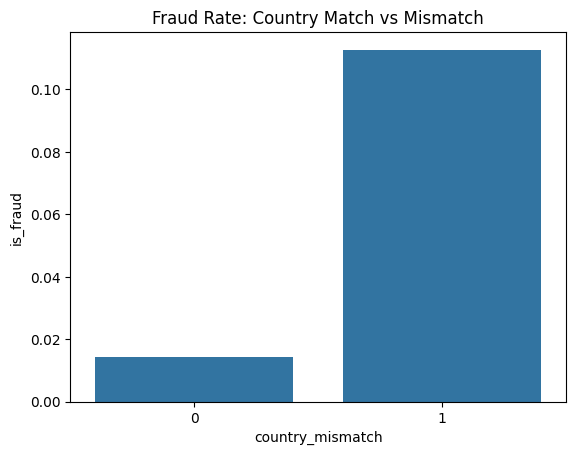

In [20]:
df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)

agg_mismatch = pd.pivot_table(
    data=df,
    index='country_mismatch',
    values='is_fraud',
    aggfunc='mean'
)

sns.barplot(x=agg_mismatch.index, y=agg_mismatch['is_fraud'])
plt.title('Fraud Rate: Country Match vs Mismatch')
plt.show()

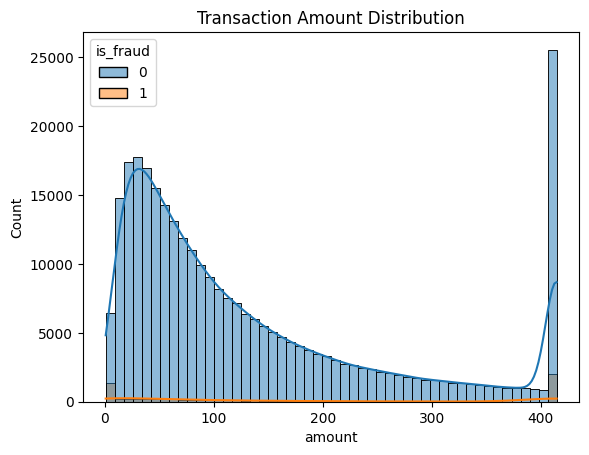

In [21]:
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

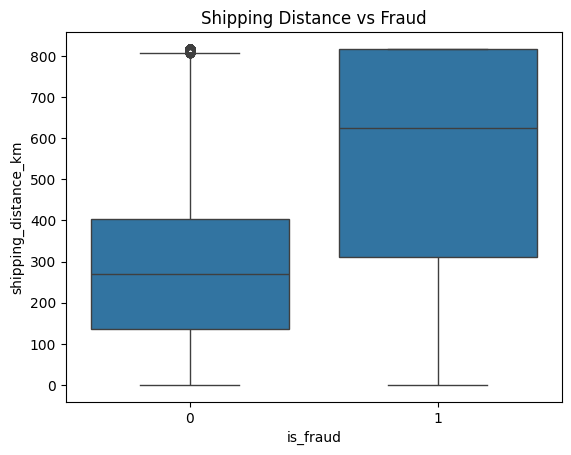

In [22]:
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df)
plt.title('Shipping Distance vs Fraud')
plt.show()

# Feature Scaling

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
import sklearn.neighbors # Required for get_knn function

# Prepare features (X) and target (y)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# One-Hot Encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_cat = encoder.fit_transform(X[categorical_cols])
X_encoded_cat_df = pd.DataFrame(X_encoded_cat, columns=encoder.get_feature_names_out(categorical_cols), index=X.index)

# Combine numerical and encoded categorical features
X_processed = pd.concat([X[numerical_cols], X_encoded_cat_df], axis=1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Data prepared for model training. X_train, X_test, y_train, y_test are defined.")

Data prepared for model training. X_train, X_test, y_train, y_test are defined.


In [24]:
# function for calculating kNN distance
def get_knn(df, n, k, metric):

    """
    Display k nearest neighbors:
    param df: Pandas DataFrame used to find similar objects within it
    param n: number of the object for which k nearest neighbors are sought
    param k: number of k nearest neighbors to be displayed
    param metric: name of the distance metric
    """

    # sklearn.neighbors is imported in the data preparation cell above
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors = k, metric = metric, algorithm = 'brute')
    nbrs.fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)

    df_res = pd.concat([
        df.iloc[nbrs_indices[0]],
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)

    return df_res

In [25]:
# Corrected feature_names to align with numerical features of the dataset
feature_names = continuous_features # These features were identified and used for outlier handling

In [26]:
transformer_mas = MaxAbsScaler().fit(df[feature_names])
df_scaled_mas = df.copy()
df_scaled_mas.loc[:, feature_names] = transformer_mas.transform(df[feature_names])
print("Features scaled using MaxAbsScaler.")

Features scaled using MaxAbsScaler.


/tmp/ipykernel_20475/475791217.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.07460317 0.07460317 0.07460317 ... 0.52698413 0.52698413 0.52698413]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled_mas.loc[:, feature_names] = transformer_mas.transform(df[feature_names])
/tmp/ipykernel_20475/475791217.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.78333333 0.78333333 0.78333333 ... 0.75       0.75       0.75      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled_mas.loc[:, feature_names] = transformer_mas.transform(df[feature_names])


In [27]:
display(get_knn(df_scaled_mas, 1, 10, 'euclidean'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,0.074603,0.783333,0.406022,0.260235,FR,FR,web,travel,0,0,0,0,0.182898,0,20,9,1,1,0,0.000000
31,0.074603,0.783333,0.406022,0.288502,FR,FR,web,gaming,0,1,1,1,0.173559,0,14,6,7,5,0,0.029769
43,0.074603,0.783333,0.406022,0.298583,FR,FR,app,electronics,0,1,1,1,0.191296,0,19,4,10,4,0,0.039257
2,0.074603,0.783333,0.406022,0.222756,FR,FR,app,travel,1,1,1,1,0.200575,0,6,12,1,4,0,0.041439
33,0.074603,0.783333,0.406022,0.228544,FR,FR,web,fashion,0,1,1,1,0.213117,0,10,17,7,2,0,0.043789
44462,0.044974,0.816667,0.410331,0.249647,ES,ES,app,gaming,0,1,1,1,0.213813,0,19,20,7,5,0,0.055457
161842,0.064021,0.800000,0.384119,0.229364,FR,FR,app,gaming,1,1,1,1,0.147179,0,2,3,4,2,0,0.055663
22570,0.034921,0.783333,0.408986,0.252035,RO,RO,web,gaming,1,0,0,0,0.226099,1,6,12,8,0,0,0.059304
279693,0.118519,0.750000,0.390981,0.262623,FR,FR,web,electronics,1,0,1,1,0.165931,0,23,19,5,6,0,0.059661
210962,0.058730,0.816667,0.375913,0.224082,RO,RO,app,travel,0,1,1,1,0.188864,0,20,1,1,0,0,0.060102


In [28]:
display(get_knn(df_scaled_mas, 1, 10, 'manhattan'))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,hour,day,month,weekday,country_mismatch,distance
1,0.074603,0.783333,0.406022,0.260235,FR,FR,web,travel,0,0,0,0,0.182898,0,20,9,1,1,0,0.000000
31,0.074603,0.783333,0.406022,0.288502,FR,FR,web,gaming,0,1,1,1,0.173559,0,14,6,7,5,0,0.037606
43,0.074603,0.783333,0.406022,0.298583,FR,FR,app,electronics,0,1,1,1,0.191296,0,19,4,10,4,0,0.046746
2,0.074603,0.783333,0.406022,0.222756,FR,FR,app,travel,1,1,1,1,0.200575,0,6,12,1,4,0,0.055156
33,0.074603,0.783333,0.406022,0.228544,FR,FR,web,fashion,0,1,1,1,0.213117,0,10,17,7,2,0,0.061909
254717,0.079365,0.716667,0.408025,0.252662,DE,DE,app,electronics,0,1,1,1,0.173865,0,1,13,4,5,0,0.090039
22570,0.034921,0.783333,0.408986,0.252035,RO,RO,web,gaming,1,0,0,0,0.226099,1,6,12,8,0,0,0.094047
184981,0.072487,0.716667,0.377559,0.255098,GB,GB,app,travel,0,1,1,1,0.180270,0,8,24,1,2,0,0.105011
44462,0.044974,0.816667,0.410331,0.249647,ES,ES,app,gaming,0,1,1,1,0.213813,0,19,20,7,5,0,0.108775
279693,0.118519,0.750000,0.390981,0.262623,FR,FR,web,electronics,1,0,1,1,0.165931,0,23,19,5,6,0,0.111644


## Normalization

In [29]:
# fit scaler on training data
std_scaler = MinMaxScaler().fit(X_train)

# transform training data
X_train_std = std_scaler.transform(X_train)
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index) # Convert back to DataFrame

# transform testing data
X_test_std = std_scaler.transform(X_test)
X_test_std_df = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index) # Convert back to DataFrame

print("Data normalized using MinMaxScaler.")

Data normalized using MinMaxScaler.


## Standardization

In [30]:
beforeScaling_lr = LogisticRegression(random_state = 42, solver='liblinear') # Added solver for robustness

In [31]:
# train model on training set
beforeScaling_lr.fit(X_train, y_train)
#  predict using test set (using X_test as validation for simplicity)
y_predict_valid_lr = beforeScaling_lr.predict(X_test)
# measuring probability using test set
y_probability_valid_lr = beforeScaling_lr.predict_proba(X_test)[:, 1]
# test performance algorithm using F1 score and auc_score
print('F1 score =', f1_score(y_test, y_predict_valid_lr))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr))

F1 score = 0.4603854389721627
AUC-ROC score = 0.9321915022767477


In [32]:
scaler = StandardScaler()

In [33]:
# Apply StandardScaler to the processed data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistent column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data standardized using StandardScaler.")

Data standardized using StandardScaler.


In [34]:
afterScaling_lr = LogisticRegression(random_state = 42, solver='liblinear') # Added solver for robustness

In [35]:
# train model on training set
afterScaling_lr.fit(X_train_scaled_df, y_train)
#  predict using test set
y_predict_valid_lr_scaled = afterScaling_lr.predict(X_test_scaled_df)
# measuring probability using test set
y_probability_valid_lr_scaled = afterScaling_lr.predict_proba(X_test_scaled_df)[:, 1]
# test performance algorithm using F1 score and auc_score
print('F1 score =', f1_score(y_test, y_predict_valid_lr_scaled))
print('AUC-ROC score =', roc_auc_score(y_test, y_probability_valid_lr_scaled))

F1 score = 0.4562533548040794
AUC-ROC score = 0.9321694482945353
